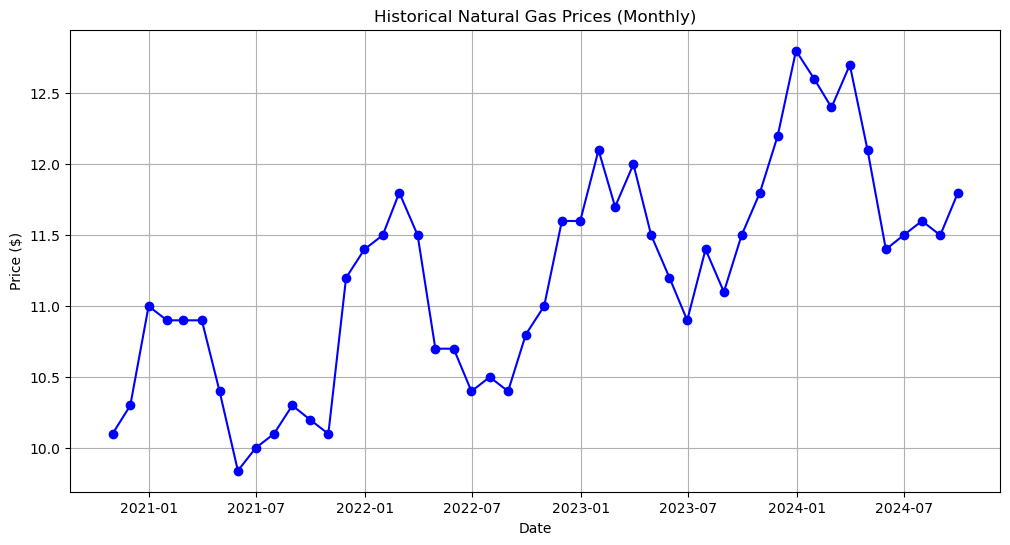

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Nat_Gas.csv') 

df['Dates'] = pd.to_datetime(df['Dates'], format='%m/%d/%y')

plt.figure(figsize=(12, 6))
plt.plot(df['Dates'], df['Prices'], marker='o', linestyle='-', color='b')
plt.title('Historical Natural Gas Prices (Monthly)')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True)
plt.show()

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv('Nat_Gas.csv')
df['Dates'] = pd.to_datetime(df['Dates'], format='%m/%d/%y')

def estimate_price(date_string):
    # Convert your text into a Python date
    target_date = pd.to_datetime(date_string)
    end_of_data = df['Dates'].max()
    
    # We turn dates into regular numbers (days)
    known_days = (df['Dates'] - df['Dates'].min()).dt.days
    target_day = (target_date - df['Dates'].min()).days
    
    # --- IF THE DATE IS IN THE PAST ---
    if target_date <= end_of_data:
        # np.interp simply finds the middle point on the line between known dates
        price = np.interp(target_day, known_days, df['Prices'])
        return price
        
    # --- IF THE DATE IS IN THE FUTURE ---
    else:
        # Step A: Find the exact same date from ONE YEAR AGO
        date_last_year = target_date - pd.DateOffset(years=1)
        day_last_year = (date_last_year - df['Dates'].min()).days
        
        # Step B: Get the price from that day last year (using the same straight line trick)
        price_last_year = np.interp(day_last_year, known_days, df['Prices'])
        
        # Step C: Add a tiny bit of growth (trend) because prices generally rise
        days_into_future = (target_date - end_of_data).days
        growth_per_day = 0.001 
        
        predicted_price = price_last_year + (days_into_future * growth_per_day)
        return predicted_price


print("Price on Jan 15, 2022 (Past):", estimate_price('2022-01-15'))
print("Price on Jan 15, 2025 (Future):", estimate_price('2025-01-15'))

Price on Jan 15, 2022 (Past): 11.448387096774194
Price on Jan 15, 2025 (Future): 12.810225806451612
